## Ejercicio 1 — C-3.50

Sea $p(x)$ un polinomio de grado $n$, es decir,

$$p(x) = \sum_{i=0}^{n} a_i x^i$$

**(a)** Describa un algoritmo simple de tiempo $O(n^2)$ para calcular $p(x)$.

**(b)** Mejore el algoritmo anterior calculando $x^i$ de una forma más eficiente.

**(c)** Ahora considere la siguiente reescritura de $p(x)$:

$$p(x) = a_0 + x\big(a_1 + x\big(a_2 + x\big(a_3 + \cdots + x(a_{n-1} + x a_n)\cdots\big)\big)\big)$$

conocida como el **método de Horner**. Usando la notación big-Oh, caracterice el número de operaciones aritméticas que ejecuta este método.

### (a) Algoritmo $O(n^2)$

In [ ]:
def cuadratico(a, x):
    # Variable donde se acumula el valor del polinomio
    p = 0

    # Recorre cada coeficiente del polinomio
    for i in range(len(a)):

        # Calcula la potencia x^i
        potencia = 1
        for j in range(i):
            potencia *= x

        # Suma el término a[i] * x^i al resultado
        p += a[i] * potencia

    # Devuelve el valor del polinomio evaluado en x
    return p

### (b) Algoritmo mejorado

In [ ]:
def mejorado(a, x):
    # Acumulador del valor del polinomio
    p = 0

    # Almacena la potencia actual de x.
    # Inicialmente x^0 = 1.
    potencia = 1

    # Recorre cada coeficiente del polinomio una sola vez
    for coef in a:

        # Suma el término coef * x^i al resultado
        p += coef * potencia

        # Calcula la siguiente potencia:
        # x^0 -> x^1 -> x^2 -> ...
        potencia *= x

    # Devuelve el valor del polinomio evaluado en x
    return p

### (c) Método de Horner

In [ ]:
def horner(a, x):
    # Inicializa el resultado con el coeficiente de mayor grado
    resultado = a[-1]

    # Recorre los coeficientes desde el penúltimo hasta el primero
    for i in range(len(a) - 2, -1, -1):

        # Aplica la fórmula de Horner:
        resultado = a[i] + x * resultado

    # Devuelve el valor del polinomio evaluado en x
    return resultado

### Verificación de resultados

Los tres algoritmos deben dar el mismo resultado para $p(x) = 3 + 2x + 5x^2 - x^3 + 4x^4$ evaluado en $x=2$.

In [ ]:
# Polinomio:
# a = [a0, a1, a2, a3, a4] -> p(x) = 3 + 2x + 5x^2 - x^3 + 4x^4

a = [3, 2, 5, -1, 4]
x = 2

print("Cuadratico:", cuadratico(a, x))
print("Mejorado:  ", mejorado(a, x))
print("Horner:    ", horner(a, x))

Cuadratico: 83
Mejorado:   83
Horner:     83


## Ejercicio 2 — División sintética

La **división sintética** permite evaluar un polinomio $p(x) = \sum_{i=0}^{n} a_i x^i$ en un valor $x = r$, dividiendo $p(x)$ entre $(x - r)$: el residuo de esa división es exactamente $p(r)$.

Programe una función `division_sintetica(a, r)` que implemente este método para evaluar el polinomio en $r$.

**Pregunta:** ¿es este método igual al método de Horner de la parte (c)? Justifique su respuesta comparando ambos algoritmos.

In [ ]:
def division_sintetica(a, r):
    # Crea una lista para almacenar los coeficientes resultantes
    b = [0] * len(a)

    # El coeficiente de mayor grado permanece igual
    b[-1] = a[-1]

    # Recorre los coeficientes desde el penúltimo hasta el primero
    for i in range(len(a)-2, -1, -1):

        # Calcula cada nuevo coeficiente utilizando la regla de la división sintética:
        # b[i] = a[i] + r * b[i+1]
        b[i] = a[i] + r * b[i+1]

    # Devuelve el residuo de dividir el polinomio por (x - r)
    return b[0]

### Verificación

`division_sintetica` debe dar el mismo resultado que `horner` para el mismo polinomio y el mismo valor de evaluación.

In [ ]:
coeficientes = [2, 3, -4, 5]
r = 2

resultado_horner = horner(coeficientes, r)
resultado_division = division_sintetica(coeficientes, r)

print("Horner:", resultado_horner)
print("División sintética:", resultado_division)

if resultado_horner == resultado_division:
    print("Correcto: los resultados son iguales.")
else:
    print("Error: los resultados son diferentes.")

Horner: 32
División sintética: 32
Correcto: los resultados son iguales.


Sí, ambos métodos son equivalentes para evaluar un polinomio.

El método de Horner evalúa el polinomio reescribiéndolo en forma anidada y recorriendo los coeficientes desde el de mayor grado hasta el de menor grado. En cada iteración realiza una multiplicación y una suma.

La división sintetica utiliza la misma recurrencia pero la diferencia es que la división sintética almacena los valores intermedios en un arreglo, mientras que Horner solo mantiene una variable acumuladora.

## Ejercicio 3 — Comparación de algoritmos

El número de operaciones ejecutadas por los algoritmos A y B es $n^2 + n$ y $\dfrac{n^3}{200}$, respectivamente.

Determine $n_0$ tal que A es mejor que B para $n \geq n_0$.

Haga una gráfica (similar a las del notebook `ch03_teoria.ipynb`) que muestre ambas funciones. Ajustar la gráfica como en el cuaderno de teoría.

In [ ]:
def encontrar_n0():
    # Iniciamos la búsqueda desde n = 1
    n = 1

    # Repetimos el proceso hasta encontrar el primer valor
    # que cumpla la condición A(n) <= B(n)
    while True:

        # Calculamos el número de operaciones del algoritmo A:
        # A(n) = n² + n
        A = n**2 + n

        # Calculamos el número de operaciones del algoritmo B:
        # B(n) = n³ / 200
        B = n**3 / 200

        # Verificamos si el algoritmo A realiza menos o igual
        # cantidad de operaciones que el algoritmo B
        if A <= B:

            # Si se cumple la condición, encontramos n0 lo devolvemos como resultado
            return n

        # Si no se cumple, aumentamos n y probamos con el siguiente valor
        n += 1


# Llamamos a la función para encontrar el valor de n0
n0 = encontrar_n0()

# Mostramos el valor encontrado
print("n0 =", n0)

n0 = 201


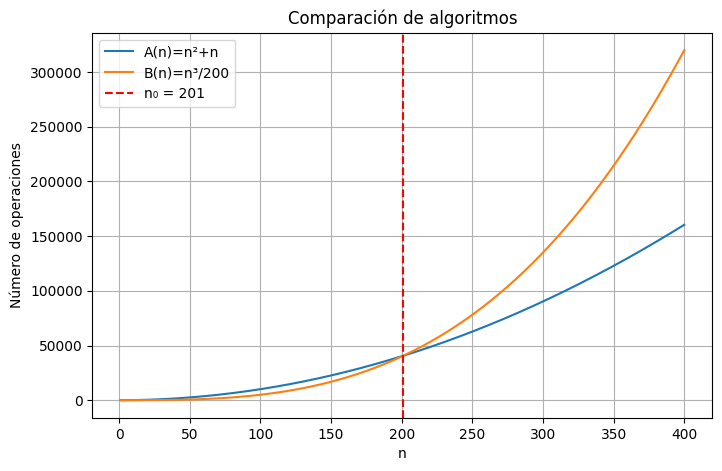

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Valores de n
n = np.arange(1, 401)

# Funciones
A = n**2 + n
B = n**3 / 200

# Gráfica
plt.figure(figsize=(8,5))

plt.plot(n, A, label='A(n)=n²+n')
plt.plot(n, B, label='B(n)=n³/200')

# Marcar n0
plt.axvline(201, color='red', linestyle='--', label='n₀ = 201')

plt.xlabel("n")
plt.ylabel("Número de operaciones")
plt.title("Comparación de algoritmos")
plt.grid(True)
plt.legend()

plt.show()

El algoritmo A realiza un número de operaciones que crece de forma cuadrática, mientras que el algoritmo B crece de forma cúbica. Para determinar a partir de qué tamaño de entrada el algoritmo A es más eficiente, se comparan ambas funciones y se busca el primer valor de n para el cual A requiere menos o igual número de operaciones que B. Mediante una búsqueda iterativa se obtiene que este valor es n0 =201. Esto significa que, para entradas de tamaño igual o mayor a 201, el algoritmo A es más eficiente, ya que su crecimiento es menor que el del algoritmo B, cuyo número de operaciones aumenta mucho más rápidamente a medida que crece el tamaño de la entrada.

## Ejercicio 4 — Three-way set disjointness

Suponiendo que es posible ordenar $n$ números en tiempo $O(n\log n)$, demuestre que es posible resolver el problema de disyunción de tres conjuntos (**three-way set disjointness**) en tiempo $O(n\log n)$.

Programe una función `disjointness_nlogn(A, B, C)` que reciba tres secuencias de tamaño $n$ y retorne `True` si no existe ningún elemento común a las tres, usando ordenamiento en vez de los tres ciclos anidados de la versión $O(n^3)$.

In [ ]:
def disjointness_nlogn(A, B, C):
    A = sorted(A)
    B = sorted(B)
    C = sorted(C)

    i = j = k = 0

    while i < len(A) and j < len(B) and k < len(C):

        if A[i] == B[j] == C[k]:
            return False      # Sí existe un elemento común

        minimo = min(A[i], B[j], C[k])

        if A[i] == minimo:
            i += 1
        elif B[j] == minimo:
            j += 1
        else:
            k += 1

    return True

In [ ]:
A = [7, 3, 1, 9]
B = [8, 5, 3, 2]
C = [6, 3, 4, 10]

print(disjointness_nlogn(A, B, C))

False


## Ejercicio 5 — R-3.28

Para cada función $f(n)$ y tiempo $t$ en la siguiente tabla, determine el tamaño más grande $n$ de un problema $P$ que puede resolverse en tiempo $t$ si el algoritmo que resuelve $P$ tarda $f(n)$ microsegundos (una entrada ya está completa).

| $f(n)$ | 1 Segundo | 1 Hora | 1 Mes | 1 Siglo |
|---|---|---|---|---|
| $\log n$ | $\approx 10^{300000}$ | | | |
| $n$ | | | | |
| $n\log n$ | | | | |
| $n^2$ | | | | |
| $2^n$ | | | | |

Complete la tabla. Puede apoyarse en una celda de código para hacer los cálculos.

In [ ]:
import math
import pandas as pd

# Tiempos en microsegundos
tiempos = {
    "1 Segundo": 1_000_000,
    "1 Hora": 3_600_000_000,
    "1 Mes": 2_592_000_000_000,        # 30 días
    "1 Siglo": 3_153_600_000_000_000   # 100 años
}

# Resolver n·log10(n) = T mediante búsqueda binaria
def resolver_nlogn(T):
    bajo, alto = 1, T
    while bajo <= alto:
        medio = (bajo + alto) // 2
        if medio * math.log10(medio) <= T:
            bajo = medio + 1
        else:
            alto = medio - 1
    return alto

# Función para escribir números en notación científica
def cientifica(x):
    if x == 0:
        return "0"
    exponente = int(math.floor(math.log10(abs(x))))
    mantisa = x / (10 ** exponente)
    return f"{mantisa:.3f}×10^{exponente}"

# Crear la tabla
tabla = pd.DataFrame(index=["log n", "n", "n log n", "n²", "2ⁿ"],
                     columns=tiempos.keys())

for nombre, T in tiempos.items():

    # log n
    tabla.loc["log n", nombre] = f"10^{T}"

    # n
    tabla.loc["n", nombre] = cientifica(T)

    # n log n
    tabla.loc["n log n", nombre] = cientifica(resolver_nlogn(T))

    # n²
    tabla.loc["n²", nombre] = cientifica(math.sqrt(T))

    # 2^n
    tabla.loc["2ⁿ", nombre] = f"{math.log2(T):.2f}"

tabla

,1 Segundo,1 Hora,1 Mes,1 Siglo
log n,10^1000000,10^3600000000,10^2592000000000,10^3153600000000000
n,1.000×10^6,3.600×10^9,2.592×10^12,3.154×10^15
n log n,1.895×10^5,4.176×10^8,2.282×10^11,2.199×10^14
n²,1.000×10^3,6.000×10^4,1.610×10^6,5.616×10^7
2ⁿ,19.93,31.75,41.24,51.49


## Ejercicio 6 — Valor más frecuente en un rango acotado
Una secuencia  S  contiene  n  enteros tomados del intervalo  [0,4n] , con repeticiones permitidas.

Describa un algoritmo eficiente para determinar un valor entero  k  que ocurre con mayor frecuencia en  S . ¿Cuál es el tiempo de ejecución de su algoritmo?

In [ ]:
import random
import time

def frecuente(S):
    n = len(S)

    frecuencia = [0] * (4 * n + 1)

    # Contar ocurrencias
    for x in S:
        frecuencia[x] += 1

    # Buscar el valor con mayor frecuencia
    k = 0
    mayor = frecuencia[0]

    for i in range(1, len(frecuencia)):
        if frecuencia[i] > mayor:
            mayor = frecuencia[i]
            k = i

    return k

In [ ]:
#Tamaño de la secuencia
n = 100000
#Secuencia aleatoria con valores entre o y 4n
secuencia = [random.randint(0, 4 * n) for _ in range(n)]

inicio = time.time()
resultado = frecuente(secuencia)
fin = time.time()

print("Valor frecuente:", resultado)
print("Tiempo de ejecución:", fin - inicio, "segundos")

Valor frecuente: 22063
Tiempo de ejecución: 0.04955720901489258 segundos


La secuencia contiene n elementos y todos los valores pertenecen al intervalo [0,4n]. La complejidad del algoritmo es O(n)

## Ejercicio 7 — Búsqueda secuencial

Dada una lista $L$ de $n$ elementos (sin ordenar) y un valor $x$, programe una función `busqueda_secuencial(L, x)` que retorne `True` si $x$ se encuentra en $L$ y `False` en caso contrario, recorriendo la lista elemento por elemento.

Analice el mejor y el peor caso de este algoritmo usando notación big-Oh.

In [ ]:
def busqueda_secuencial(lista, x):
    for elemento in lista:
        if elemento == x:
            return True
    return False

In [ ]:
k = [8, 3, 12, 7, 5]

print(busqueda_secuencial(k, 7))
print(busqueda_secuencial(k, 10))

True
False


La búsqueda secuencial recorre la lista elemento por elemento hasta encontrar el valor buscado o llegar al final de la lista. En el mejor caso, el elemento se encuentra en la primera posición, por lo que solo se realiza una comparación y la complejidad es O(1). En el peor caso, el elemento está en la última posición o no se encuentra en la lista, por lo que es necesario recorrer los n elementos y la complejidad es O(n).

## Ejercicio 8 — Búsqueda binaria
Dada una lista  L  ordenada de  n  elementos y un valor  x , programe una función busqueda_binaria(L, x) que retorne True si  x  se encuentra en  L  y False en caso contrario, descartando en cada paso la mitad de los elementos restantes.

¿Cuál es el tiempo de ejecución de este algoritmo, usando notación big-Oh? Compárelo con el de la búsqueda secuencial del ejercicio anterior.

In [ ]:
def busqueda_binaria(L, x):
    # Índice inicial de la lista
    inicio = 0

    # Índice final de la lista
    fin = len(L) - 1


    while inicio <= fin:

        # Calcular la posición central
        medio = (inicio + fin) // 2

        # Si el elemento central es el buscado, se encontró
        if L[medio] == x:
            return True

        # Si el valor buscado es menor que el elemento central,
        # continuar buscando en la mitad izquierda
        if x < L[medio]:
            fin = medio - 1

        # En caso contrario, buscar en la mitad derecha
        else:
            inicio = medio + 1

    # Si termina el ciclo, el elemento no está en la lista
    return False

In [ ]:

L = list(range(1, 100001))   # Lista con 100000 elementos
x = 99999                    # Valor a buscar

# Medición del tiempo de ejecución
inicio = time.time()

resultado = busqueda_binaria(L, x)

fin = time.time()

print("¿Se encontró el elemento?:", resultado)
print("Tiempo de ejecución:", fin - inicio, "segundos")

¿Se encontró el elemento?: True
Tiempo de ejecución: 0.00012803077697753906 segundos


La búsqueda secuencial recorre los elementos de la lista uno por uno hasta encontrar el valor buscado o llegar al final. En el mejor caso, el elemento se encuentra en la primera posición y la complejidad es O(1). En el peor caso, debe recorrer toda la lista, por lo que su complejidad es O(n).

La búsqueda binaria, en cambio, requiere que la lista esté ordenada. En cada iteración compara el elemento buscado con el elemento central y descarta la mitad de los elementos restantes. En el mejor caso también tiene complejidad O(1), mientras que en el peor caso su complejidad es O(logn).

Por lo tanto, la búsqueda binaria es más eficiente que la búsqueda secuencial para listas ordenadas, ya que el número de comparaciones crece de forma logarítmica en lugar de lineal.